<a href="https://colab.research.google.com/github/AKSHAYBHAMMAR/FLIGHT_RISK_PREDICTION_SYSTEM/blob/main/flight_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter Departure City: mumbai
Enter Destination City: vadodara

===== ROUTE ANALYSIS =====

📍 City: Mumbai
🌡 Temp: 28.03°C
💨 Wind: 4.12 m/s
👁 Visibility: 4.0 km
💧 Humidity: 74%
📏 Distance: 59.9 km
⏱ Delay: 97.7 min

📍 City: Palghar Taluka
🌡 Temp: 25.7°C
💨 Wind: 1.26 m/s
👁 Visibility: 10.0 km
💧 Humidity: 78%
📏 Distance: 119.81 km
⏱ Delay: 92.67 min

📍 City: Vapi
🌡 Temp: 26.11°C
💨 Wind: 1.46 m/s
👁 Visibility: 10.0 km
💧 Humidity: 75%
📏 Distance: 179.71 km
⏱ Delay: 92.82 min

📍 City: Bardoli Taluka
🌡 Temp: 26.6°C
💨 Wind: 2.47 m/s
👁 Visibility: 10.0 km
💧 Humidity: 68%
📏 Distance: 239.61 km
⏱ Delay: 92.36 min

📍 City: Jhagadiya Taluka
🌡 Temp: 27.41°C
💨 Wind: 2.08 m/s
👁 Visibility: 10.0 km
💧 Humidity: 59%
📏 Distance: 299.51 km
⏱ Delay: 91.0 min

📍 City: Vadodara
🌡 Temp: 27.78°C
💨 Wind: 3.09 m/s
👁 Visibility: 10.0 km
💧 Humidity: 56%
📏 Distance: 359.42 km
⏱ Delay: 92.22 min

===== FINAL RESULT =====
✈ Route: Mumbai → Vadodara
🛣 Path: Mumbai → Palghar Taluka → Vapi → Bardoli Taluka → Jhagadiya Ta

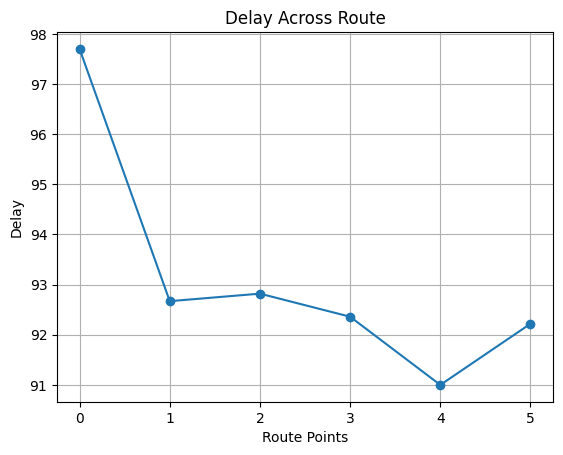

In [1]:
# ================== IMPORTS ==================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


# ================== WEATHER API ==================
API_KEY = "1ba7a5c4137bda36dd6a1b0736778a63"

# ================== DISTANCE ==================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


# ================== API FUNCTIONS ==================
def get_coordinates(city):
    city = city.strip()  # ✅ FIX: remove extra spaces

    try:
        url = f"http://api.openweathermap.org/geo/1.0/direct?q={city}&limit=1&appid={API_KEY}"
        response = requests.get(url, timeout=5)
        data = response.json()

        if not data:
            raise ValueError(f"City '{city}' not found.")

        return data[0]['lat'], data[0]['lon']

    except Exception as e:
        print(f"❌ Error: {e}")
        return None, None


def get_weather(lat, lon):
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
        response = requests.get(url, timeout=5)
        data = response.json()

        temp = data['main']['temp']
        humidity = data['main']['humidity']
        wind = data['wind']['speed']
        visibility = data.get('visibility', 10000) / 1000

        return temp, wind, visibility, humidity

    except:
        # fallback values
        return 30, 10, 6, 70


def get_city_name(lat, lon):
    try:
        url = f"http://api.openweathermap.org/geo/1.0/reverse?lat={lat}&lon={lon}&limit=1&appid={API_KEY}"
        response = requests.get(url, timeout=5)
        data = response.json()

        if data:
            return data[0]['name']

    except:
        pass

    return "Unknown"


# ================== ROUTE ==================
def get_route_points(lat1, lon1, lat2, lon2, num_points=6):
    lats = np.linspace(lat1, lat2, num_points)
    lons = np.linspace(lon1, lon2, num_points)

    return list(zip(lons, lats))


# ================== DATA ==================
data = []

for _ in range(200):
    distance = np.random.randint(100, 2000)
    temp = np.random.randint(20, 40)
    wind = np.random.randint(5, 20)
    visibility = np.random.randint(2, 10)
    humidity = np.random.randint(40, 90)

    delay = (
        distance * 0.02 +
        (40 - visibility) * 2 +
        humidity * 0.1 +
        wind * 1.5 +
        np.random.randint(0, 10)
    )

    data.append([distance, temp, wind, visibility, humidity, delay])

df = pd.DataFrame(data, columns=[
    'distance_km', 'temperature', 'wind_speed',
    'visibility', 'humidity', 'delay_minutes'
])

feature_columns = ['temperature', 'wind_speed', 'visibility', 'humidity', 'distance_km']

X = df[feature_columns]
y = df['delay_minutes']


# ================== MODEL ==================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)


# ================== PREDICTION ==================
def predict_delay(temp, wind, vis, hum, distance):
    input_df = pd.DataFrame({
        'temperature': [temp],
        'wind_speed': [wind],
        'visibility': [vis],
        'humidity': [hum],
        'distance_km': [distance]
    })

    return round(model.predict(input_df)[0], 2)


# ================== MAIN ==================
def analyze_route(departure, destination):

    lat1, lon1 = get_coordinates(departure)
    lat2, lon2 = get_coordinates(destination)

    if lat1 is None or lat2 is None:
        print("❌ Cannot proceed due to invalid city.")
        return

    total_distance = haversine(lat1, lon1, lat2, lon2)

    route_points = get_route_points(lat1, lon1, lat2, lon2)

    route_cities = []
    delays = []

    print("\n===== ROUTE ANALYSIS =====")

    for i, (lon, lat) in enumerate(route_points):

        temp, wind, vis, hum = get_weather(lat, lon)

        distance = (i + 1) / len(route_points) * total_distance

        delay = predict_delay(temp, wind, vis, hum, distance)

        city = get_city_name(lat, lon)

        if city not in route_cities and city != "Unknown":
            route_cities.append(city)

        delays.append(delay)

        print(f"\n📍 City: {city}")
        print(f"🌡 Temp: {temp}°C")
        print(f"💨 Wind: {wind} m/s")
        print(f"👁 Visibility: {vis} km")
        print(f"💧 Humidity: {hum}%")
        print(f"📏 Distance: {round(distance, 2)} km")
        print(f"⏱ Delay: {delay} min")

    avg_delay = sum(delays) / len(delays)

    print("\n===== FINAL RESULT =====")
    print(f"✈ Route: {departure.strip().title()} → {destination.strip().title()}")
    print(f"🛣 Path: {' → '.join(route_cities)}")
    print(f"📏 Total Distance: {round(total_distance, 2)} km")
    print(f"⏱ Avg Delay: {round(avg_delay, 2)} min")

    # Plot
    plt.figure()
    plt.plot(delays, marker='o')
    plt.title("Delay Across Route")
    plt.xlabel("Route Points")
    plt.ylabel("Delay")
    plt.grid()
    plt.show()


# ================== RUN ==================
if __name__ == "__main__":
    departure = input("Enter Departure City: ")
    destination = input("Enter Destination City: ")

    analyze_route(departure, destination)